# Sampling strategies



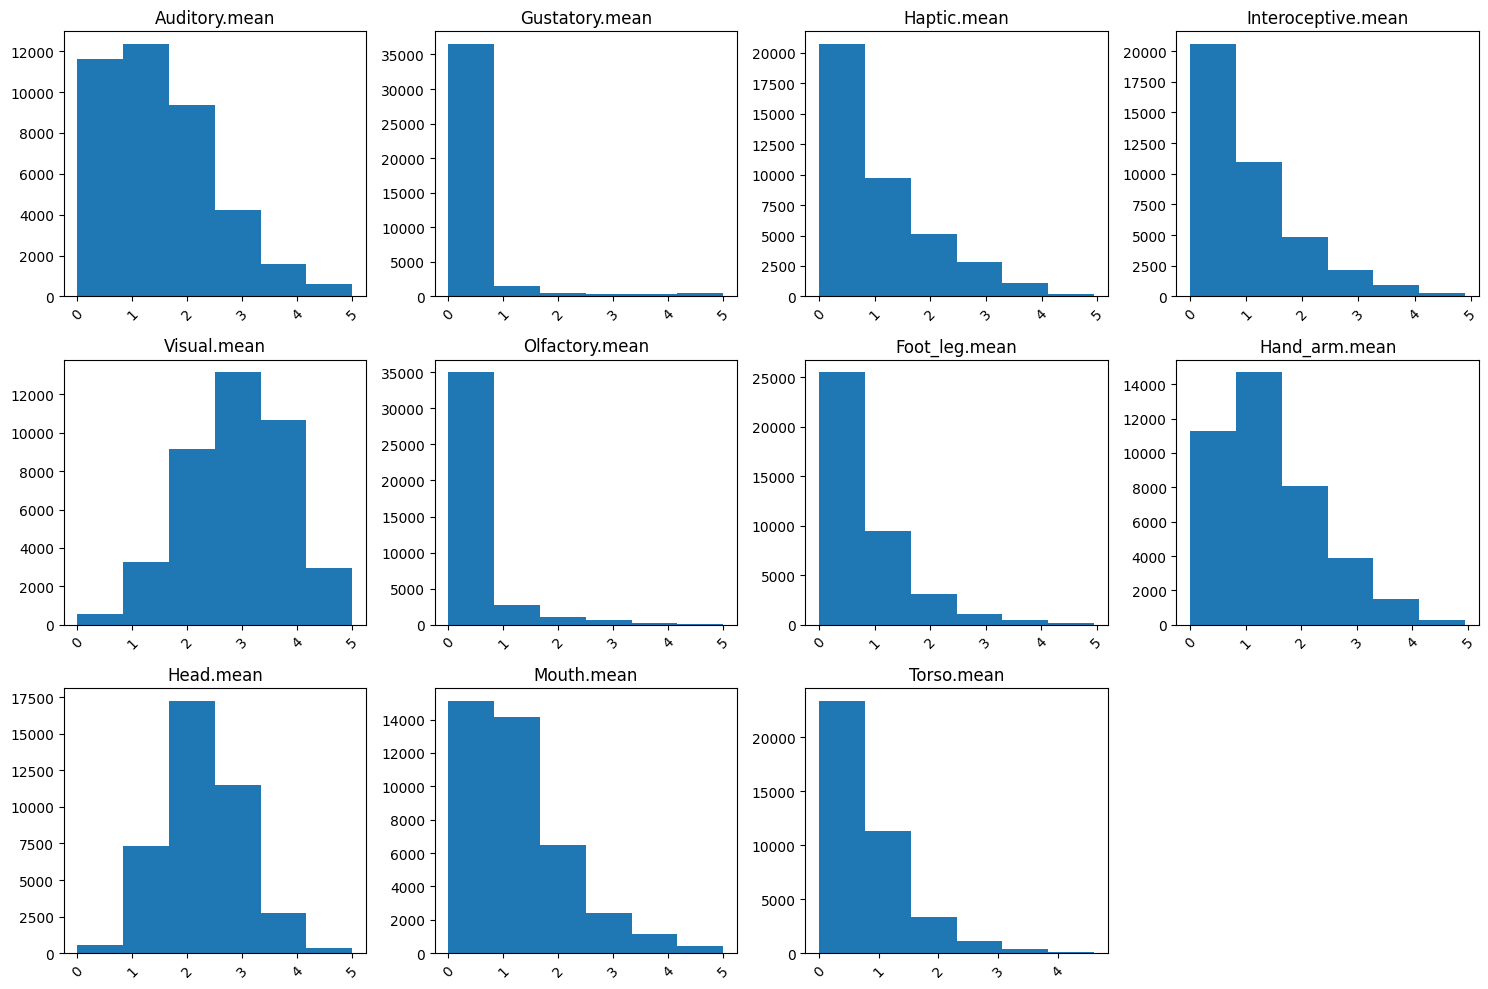

In [43]:
import pandas as pd
from sklearn.model_selection import train_test_split

random_state = 42
df = pd.read_csv('Sensorimotor_norms_12Oct2025.csv')


import matplotlib.pyplot as plt
cols = ['Auditory.mean','Gustatory.mean','Haptic.mean','Interoceptive.mean',
        'Visual.mean','Olfactory.mean','Foot_leg.mean','Hand_arm.mean',
        'Head.mean','Mouth.mean','Torso.mean']
fig, axes = plt.subplots(3, 4, figsize=(15, 10))  # 增大 figsize
axes = axes.flatten()
for ax, col in zip(axes, cols):
    df[col].dropna().hist(bins=6, ax=ax)
    ax.set_title(col)
    ax.tick_params(axis='x', rotation=45)
    ax.grid(False)
# 关闭多余子图（第 12 个）
if len(cols) < len(axes):
    for ax in axes[len(cols):]:
        ax.set_visible(False)
plt.tight_layout()
plt.show()


## 1. Random_sample

Number of words in train set: 35736
Number of words in test set: 3971


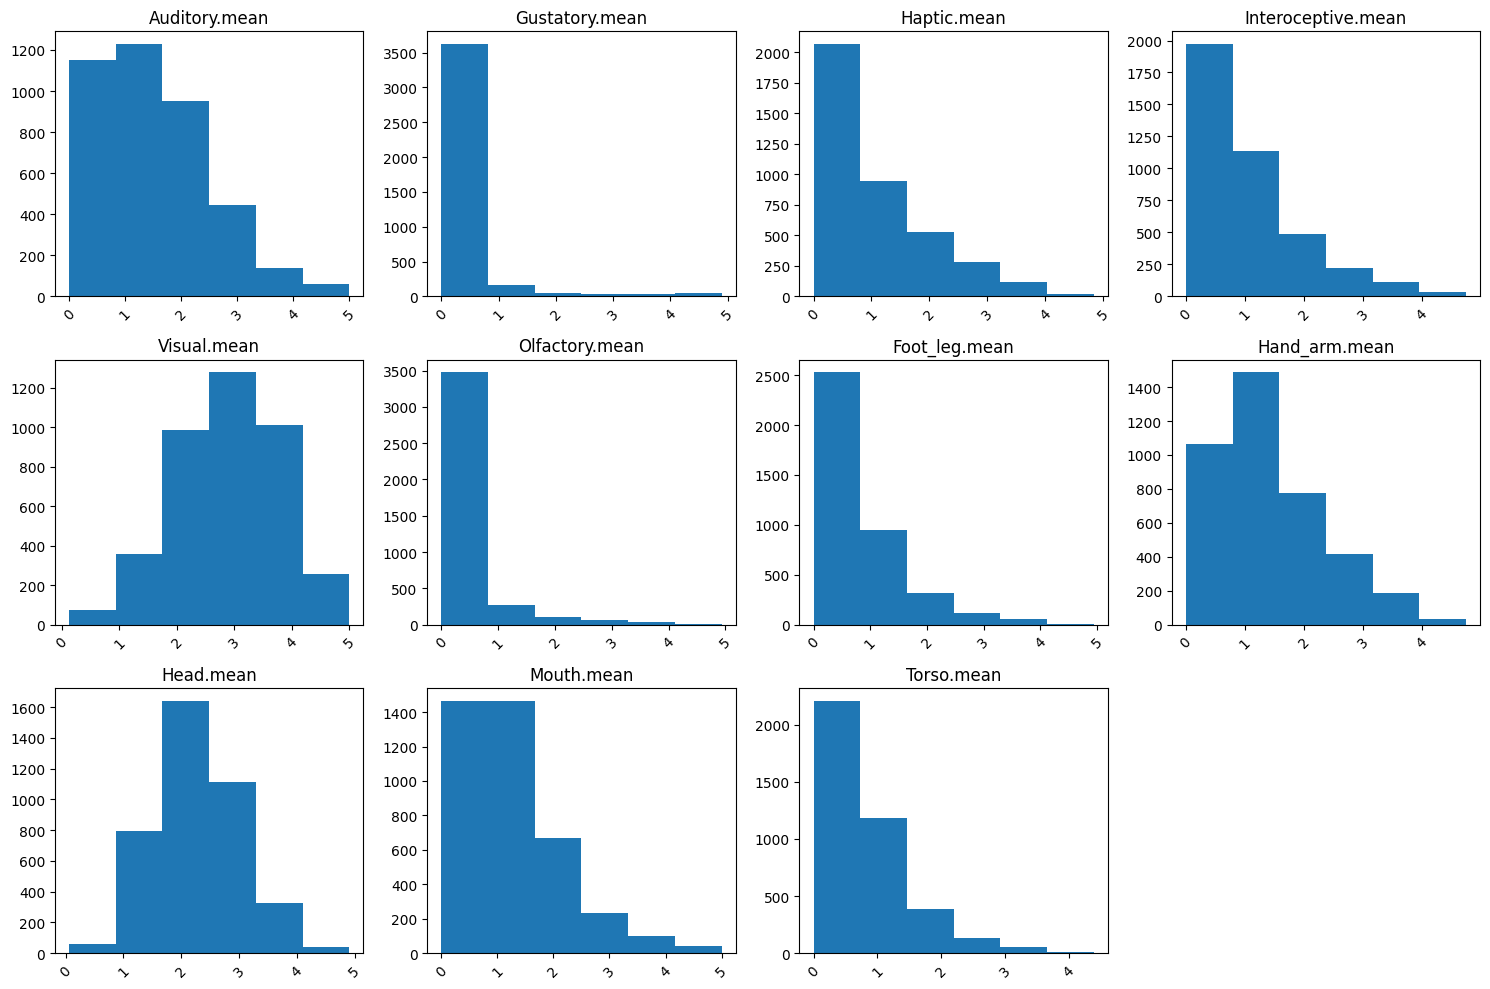

In [44]:
import pandas as pd
from sklearn.model_selection import train_test_split

random_state = 42
df_1 = pd.read_csv('Sensorimotor_norms_12Oct2025.csv')
df_1_train, df_1_test = train_test_split(df_1, test_size=0.1, random_state=random_state)

print(f"Number of words in train set: {len(df_1_train)}")
print(f"Number of words in test set: {len(df_1_test)}")

import matplotlib.pyplot as plt
cols = ['Auditory.mean','Gustatory.mean','Haptic.mean','Interoceptive.mean',
        'Visual.mean','Olfactory.mean','Foot_leg.mean','Hand_arm.mean',
        'Head.mean','Mouth.mean','Torso.mean']
fig, axes = plt.subplots(3, 4, figsize=(15, 10))  # 增大 figsize
axes = axes.flatten()
for ax, col in zip(axes, cols):
    df_1_test[col].dropna().hist(bins=6, ax=ax)
    ax.set_title(col)
    ax.tick_params(axis='x', rotation=45)
    ax.grid(False)
# 关闭多余子图（第 12 个）
if len(cols) < len(axes):
    for ax in axes[len(cols):]:
        ax.set_visible(False)
plt.tight_layout()
plt.show()



In [45]:
df_1_test.to_excel('sensorimotor_random_sample.xlsx', index=False)

## split for fine_tuning

In [46]:
import pandas as pd
from sklearn.model_selection import train_test_split

random_state = 42
df_2 = df_1_test
df_2_train, df_2_test = train_test_split(df_2, test_size=0.4, random_state=random_state)

print(f"Number of words in train set: {len(df_2_train)}")
print(f"Number of words in test set: {len(df_2_test)}")


Number of words in train set: 2382
Number of words in test set: 1589


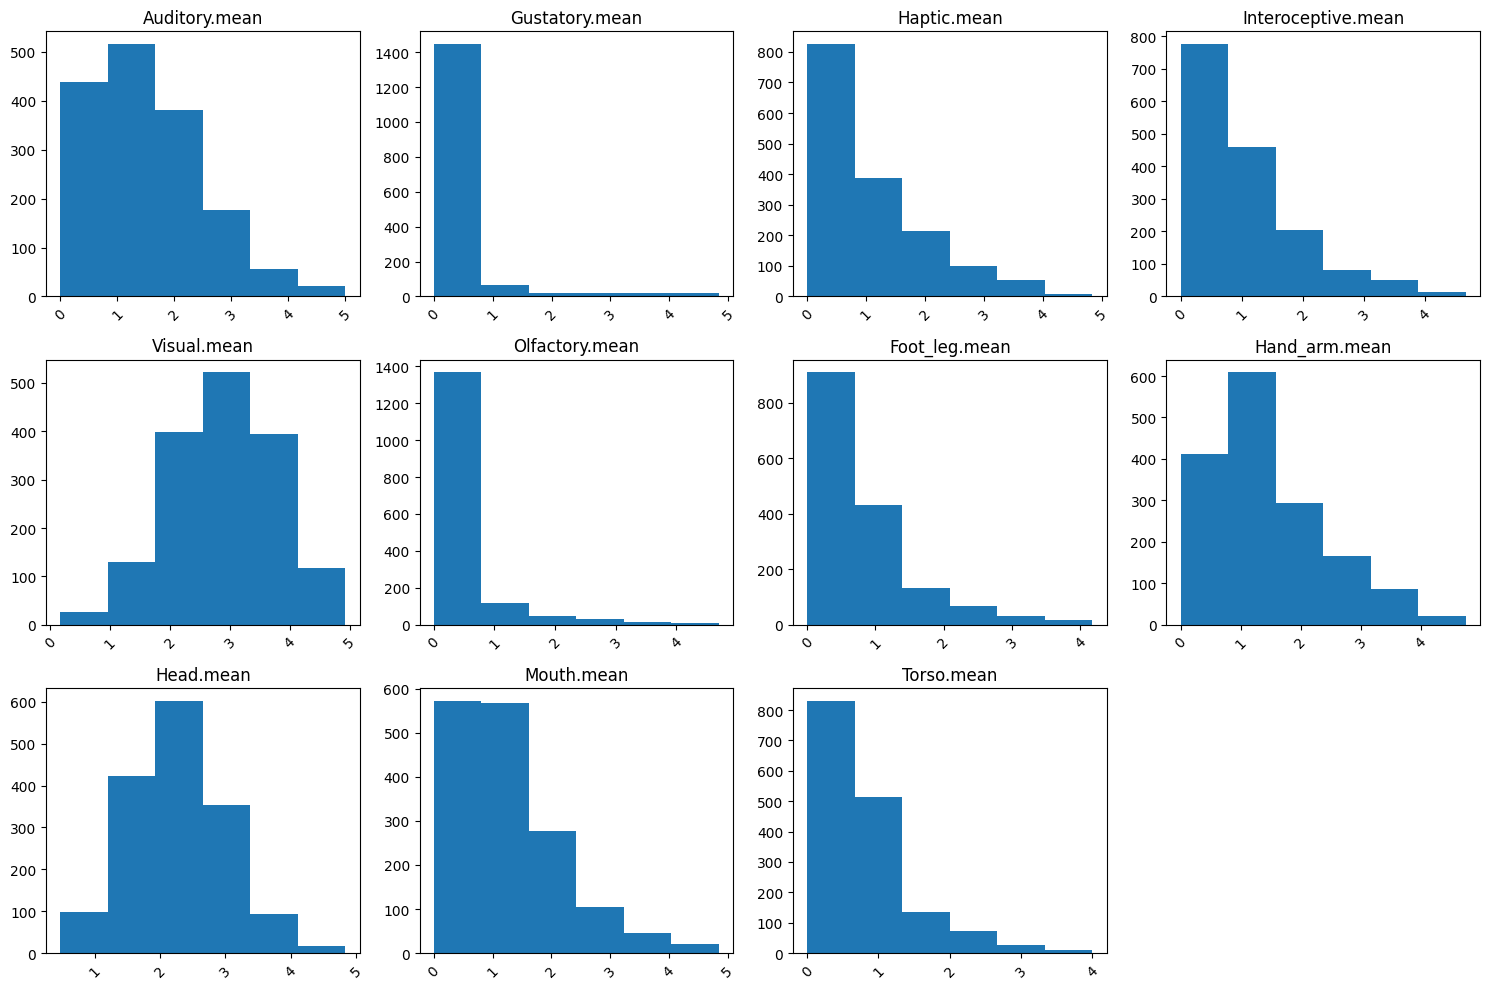

In [47]:

import matplotlib.pyplot as plt
cols = ['Auditory.mean','Gustatory.mean','Haptic.mean','Interoceptive.mean',
        'Visual.mean','Olfactory.mean','Foot_leg.mean','Hand_arm.mean',
        'Head.mean','Mouth.mean','Torso.mean']
fig, axes = plt.subplots(3, 4, figsize=(15, 10))  # 增大 figsize
axes = axes.flatten()
for ax, col in zip(axes, cols):
    df_2_test[col].dropna().hist(bins=6, ax=ax)
    ax.set_title(col)
    ax.tick_params(axis='x', rotation=45)
    ax.grid(False)
# 关闭多余子图（第 12 个）
if len(cols) < len(axes):
    for ax in axes[len(cols):]:
        ax.set_visible(False)
plt.tight_layout()
plt.show()

In [48]:
df_2_test.to_excel('1_test_sensorimotor_random_sample.xlsx', index=False)
df_2_train.to_excel('1_train_sensorimotor_random_sample.xlsx', index=False)

# study2 Dutch & English

任务：
流程：
prepare data: 
1. Filter1: translate dutch word to english word and then translate back to dutch, select the words with the original word same with the tranlated back words.
2. Filter2: select common words both in dutch norms and english norms
3. combine data: english and dutch norms

In [49]:
import pandas as pd
df_english = pd.read_csv("Sensorimotor_norms_12Oct2025.csv")
df_dutch = pd.read_excel("Words_Speed_Brysbaert_with_English_translation_and_back_translation.xlsx")

In [50]:
df_dutch.columns

Index(['Original_word', 'Deepl_translation_English', 'Back_translation',
       'Include?'],
      dtype='object')

In [51]:
df_dutch_filtered = df_dutch[df_dutch['Include?'] == 1]

In [52]:
len(df_dutch_filtered)

10677

In [53]:
df_english.columns

Index(['Word', 'Auditory.mean', 'Gustatory.mean', 'Haptic.mean',
       'Interoceptive.mean', 'Olfactory.mean', 'Visual.mean', 'Foot_leg.mean',
       'Hand_arm.mean', 'Head.mean', 'Mouth.mean', 'Torso.mean', 'Auditory.SD',
       'Gustatory.SD', 'Haptic.SD', 'Interoceptive.SD', 'Olfactory.SD',
       'Visual.SD', 'Foot_leg.SD', 'Hand_arm.SD', 'Head.SD', 'Mouth.SD',
       'Torso.SD', 'N_known.perceptual', 'N_known.action'],
      dtype='object')

In [54]:
df_english["_eng_norm"] = df_english["Word"].astype(str).str.strip().str.lower()
df_dutch_filtered["_eng_norm"] = df_dutch_filtered["Deepl_translation_English"].astype(str).str.strip().str.lower()

/var/folders/tb/rtz1nxvn4k5_jn2c158qm_wm0000gn/T/ipykernel_28681/73588925.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_dutch_filtered["_eng_norm"] = df_dutch_filtered["Deepl_translation_English"].astype(str).str.strip().str.lower()


In [55]:
# 内连接（只保留两边都有的词）
merged = pd.merge(df_english, df_dutch_filtered[["Original_word", "Deepl_translation_English", "_eng_norm"]],
                      on="_eng_norm", how="inner", validate="m:m")

    

In [56]:
merged.columns

Index(['Word', 'Auditory.mean', 'Gustatory.mean', 'Haptic.mean',
       'Interoceptive.mean', 'Olfactory.mean', 'Visual.mean', 'Foot_leg.mean',
       'Hand_arm.mean', 'Head.mean', 'Mouth.mean', 'Torso.mean', 'Auditory.SD',
       'Gustatory.SD', 'Haptic.SD', 'Interoceptive.SD', 'Olfactory.SD',
       'Visual.SD', 'Foot_leg.SD', 'Hand_arm.SD', 'Head.SD', 'Mouth.SD',
       'Torso.SD', 'N_known.perceptual', 'N_known.action', '_eng_norm',
       'Original_word', 'Deepl_translation_English'],
      dtype='object')

In [57]:
df_speedbrysbaert = pd.read_excel("SpeedBrysbaert_Norms.xlsx")

In [58]:
df_speedbrysbaert.columns

Index(['Woord', 'Horen', 'Zien', 'Ruiken', 'Proeven', 'Voelen', 'Sensaties',
       'Modality', 'ModalityExclusivity', 'MaxPercStrength',
       'AvModalityStrength', 'Minkowski3', 'Concreteness',
       'ConcretenessCategory', 'Imageability', 'ImageabilityCategory',
       'SourceImageability', 'Frequency', 'Prevalence', 'Length', 'Nsyl',
       'N_phonemes', 'PoS', 'OLD20', 'DLP_RT', 'DLP_Acc', 'DCP_RT', 'DCP_Acc'],
      dtype='object')

In [59]:
merged.rename(columns={'Original_word':'Woord'}, inplace=True)

In [60]:
lancaster_speedbrysbaert_norms = pd.merge(merged, df_speedbrysbaert, on="Woord", how="inner")

In [61]:
lancaster_speedbrysbaert_norms

,Word,Auditory.mean,Gustatory.mean,Haptic.mean,Interoceptive.mean,Olfactory.mean,Visual.mean,Foot_leg.mean,Hand_arm.mean,Head.mean,...,Prevalence,Length,Nsyl,N_phonemes,PoS,OLD20,DLP_RT,DLP_Acc,DCP_RT,DCP_Acc
0,ABACUS,1.556,0.167,3.722,0.278,0.111,3.944,0.000,2.474,2.632,...,2.737364,7,2,6,N,2.80,621.580000,0.829268,994.43,0.99
1,ABANDON,0.941,0.118,0.294,2.118,0.059,2.176,1.100,0.700,2.450,...,2.849062,8,3,7,WW,1.35,476.680294,1.000000,948.73,1.00
2,ABBREVIATE,2.400,0.000,0.150,0.450,0.000,2.650,0.158,2.105,2.000,...,2.128239,8,3,7,WW,1.80,573.883333,0.878049,1091.43,0.99
3,ABBREVIATION,2.737,0.053,0.158,0.474,0.000,3.947,0.000,0.444,1.333,...,2.383672,9,3,8,N,2.35,530.200000,1.000000,1031.21,0.99
4,ABDOMINAL,0.933,0.200,3.200,2.733,0.200,3.800,0.333,0.476,0.857,...,1.383079,10,4,9,ADJ,3.55,730.724000,0.829268,1618.13,0.82
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7856,ZINC,0.100,1.150,0.800,0.450,0.350,1.950,0.235,1.000,0.941,...,2.727711,4,1,4,N,1.15,531.960000,0.902439,967.98,1.00
7857,ZIPPER,2.400,0.000,3.600,0.400,0.000,4.000,0.857,4.000,1.571,...,2.609017,12,3,9,N,3.50,638.619167,0.878049,1234.08,1.00
7858,ZOO,2.933,0.067,2.067,0.733,2.933,3.533,2.692,1.692,3.923,...,2.721282,10,3,7,N,3.60,554.631795,1.000000,994.78,1.00
7859,ZOOM IN,0.474,0.105,0.316,0.158,0.105,3.789,0.300,1.650,3.150,...,2.252273,8,3,6,WW,2.00,555.722500,0.923077,1082.31,0.99


In [63]:
lancaster_speedbrysbaert_norms.columns

Index(['Word', 'Auditory.mean', 'Gustatory.mean', 'Haptic.mean',
       'Interoceptive.mean', 'Olfactory.mean', 'Visual.mean', 'Foot_leg.mean',
       'Hand_arm.mean', 'Head.mean', 'Mouth.mean', 'Torso.mean', 'Auditory.SD',
       'Gustatory.SD', 'Haptic.SD', 'Interoceptive.SD', 'Olfactory.SD',
       'Visual.SD', 'Foot_leg.SD', 'Hand_arm.SD', 'Head.SD', 'Mouth.SD',
       'Torso.SD', 'N_known.perceptual', 'N_known.action', '_eng_norm',
       'Woord', 'Deepl_translation_English', 'Horen', 'Zien', 'Ruiken',
       'Proeven', 'Voelen', 'Sensaties', 'Modality', 'ModalityExclusivity',
       'MaxPercStrength', 'AvModalityStrength', 'Minkowski3', 'Concreteness',
       'ConcretenessCategory', 'Imageability', 'ImageabilityCategory',
       'SourceImageability', 'Frequency', 'Prevalence', 'Length', 'Nsyl',
       'N_phonemes', 'PoS', 'OLD20', 'DLP_RT', 'DLP_Acc', 'DCP_RT', 'DCP_Acc'],
      dtype='object')

In [64]:
lancaster_speedbrysbaert_norms = lancaster_speedbrysbaert_norms.drop(columns=['_eng_norm', 'Deepl_translation_English'], errors='ignore')

In [68]:
lancaster_speedbrysbaert_norms.to_excel("lancaster_speedbrysbaert_common_norms.xlsx", index=False)

### 查看与study1中的数据有多少重合

In [ ]:
df_sample=pd.read_excel("sensorimotor_random_sample.xlsx")

In [ ]:
df_sample["_eng_norm"] = df_sample["Word"].astype(str).str.strip().str.lower()

In [ ]:
len(df_sample)

3971

In [ ]:
result["_eng_norm"] = result["English"].astype(str).str.strip().str.lower()

In [ ]:
# 内连接（只保留两边都有的词）
merged_sample = pd.merge(df_sample, result[["Dutch", "English", "_eng_norm"]],
                      on="_eng_norm", how="inner", validate="m:m")

In [31]:
len(merged_sample)

825

### sample
50% from the 7861 words
40% for test and 60% for training

In [70]:
random_state = 42
df_common = lancaster_speedbrysbaert_norms
df_common_train, df_common_test = train_test_split(df_common, test_size=0.5, random_state=random_state)

print(f"Number of words in train set: {len(df_common_train)}")
print(f"Number of words in test set: {len(df_common_test)}")


Number of words in train set: 3930
Number of words in test set: 3931


In [71]:
random_state = 42
df_2 = df_common_train
df_2_train, df_2_test = train_test_split(df_2, test_size=0.4, random_state=random_state)

print(f"Number of words in train set: {len(df_2_train)}")
print(f"Number of words in test set: {len(df_2_test)}")


Number of words in train set: 2358
Number of words in test set: 1572


In [73]:
df_2_test.to_excel('2_test_sensorimotor_random_sample.xlsx', index=False)
df_2_train.to_excel('2_train_sensorimotor_random_sample.xlsx', index=False)

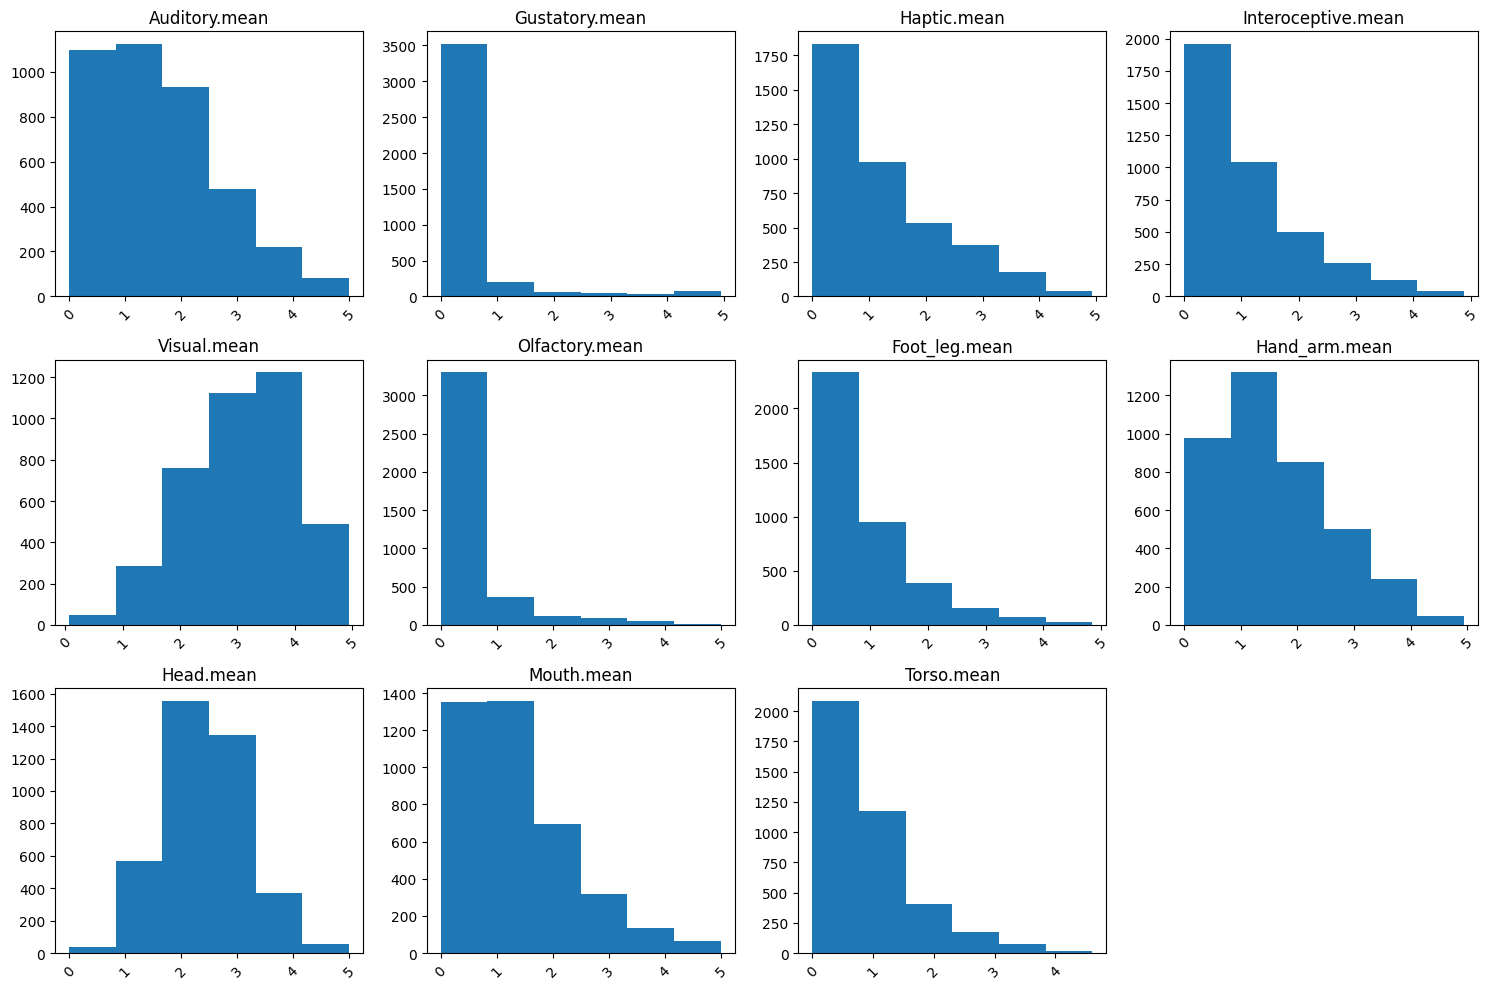

In [75]:

import matplotlib.pyplot as plt
cols = ['Auditory.mean','Gustatory.mean','Haptic.mean','Interoceptive.mean',
        'Visual.mean','Olfactory.mean','Foot_leg.mean','Hand_arm.mean',
        'Head.mean','Mouth.mean','Torso.mean']
fig, axes = plt.subplots(3, 4, figsize=(15, 10))  # 增大 figsize
axes = axes.flatten()
for ax, col in zip(axes, cols):
    df_common_train[col].dropna().hist(bins=6, ax=ax)
    ax.set_title(col)
    ax.tick_params(axis='x', rotation=45)
    ax.grid(False)
# 关闭多余子图（第 12 个）
if len(cols) < len(axes):
    for ax in axes[len(cols):]:
        ax.set_visible(False)
plt.tight_layout()
plt.show()

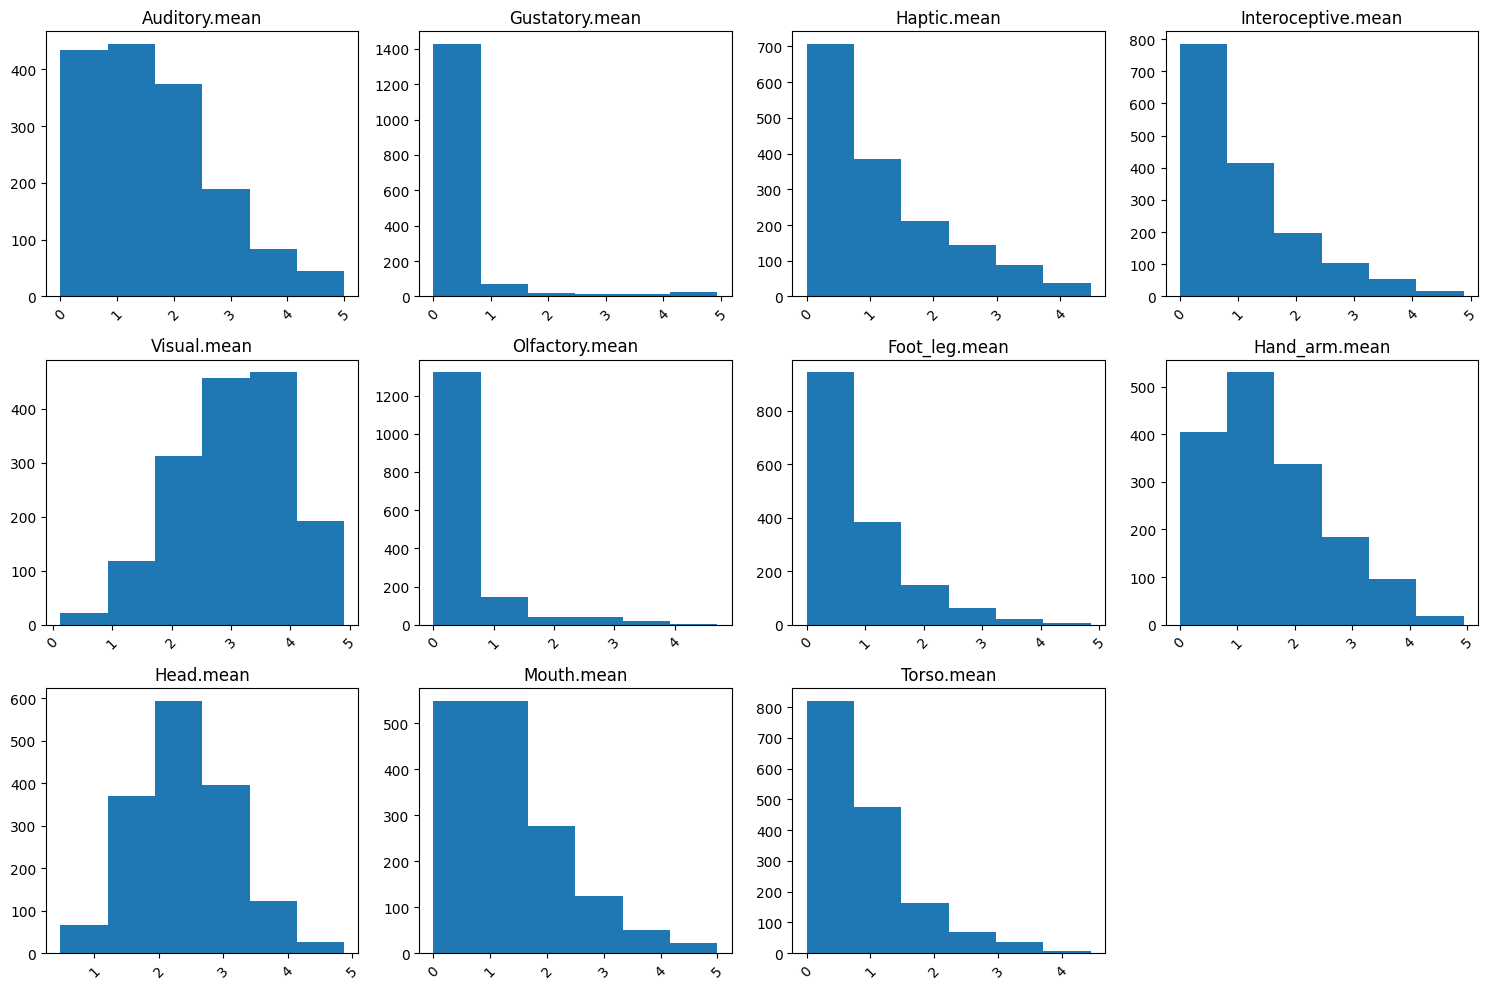

In [76]:
import matplotlib.pyplot as plt
cols = ['Auditory.mean','Gustatory.mean','Haptic.mean','Interoceptive.mean',
        'Visual.mean','Olfactory.mean','Foot_leg.mean','Hand_arm.mean',
        'Head.mean','Mouth.mean','Torso.mean']
fig, axes = plt.subplots(3, 4, figsize=(15, 10))  # 增大 figsize
axes = axes.flatten()
for ax, col in zip(axes, cols):
    df_2_test[col].dropna().hist(bins=6, ax=ax)
    ax.set_title(col)
    ax.tick_params(axis='x', rotation=45)
    ax.grid(False)
# 关闭多余子图（第 12 个）
if len(cols) < len(axes):
    for ax in axes[len(cols):]:
        ax.set_visible(False)
plt.tight_layout()
plt.show()

In [77]:
df_common_train.columns

Index(['Word', 'Auditory.mean', 'Gustatory.mean', 'Haptic.mean',
       'Interoceptive.mean', 'Olfactory.mean', 'Visual.mean', 'Foot_leg.mean',
       'Hand_arm.mean', 'Head.mean', 'Mouth.mean', 'Torso.mean', 'Auditory.SD',
       'Gustatory.SD', 'Haptic.SD', 'Interoceptive.SD', 'Olfactory.SD',
       'Visual.SD', 'Foot_leg.SD', 'Hand_arm.SD', 'Head.SD', 'Mouth.SD',
       'Torso.SD', 'N_known.perceptual', 'N_known.action', 'Woord', 'Horen',
       'Zien', 'Ruiken', 'Proeven', 'Voelen', 'Sensaties', 'Modality',
       'ModalityExclusivity', 'MaxPercStrength', 'AvModalityStrength',
       'Minkowski3', 'Concreteness', 'ConcretenessCategory', 'Imageability',
       'ImageabilityCategory', 'SourceImageability', 'Frequency', 'Prevalence',
       'Length', 'Nsyl', 'N_phonemes', 'PoS', 'OLD20', 'DLP_RT', 'DLP_Acc',
       'DCP_RT', 'DCP_Acc'],
      dtype='object')

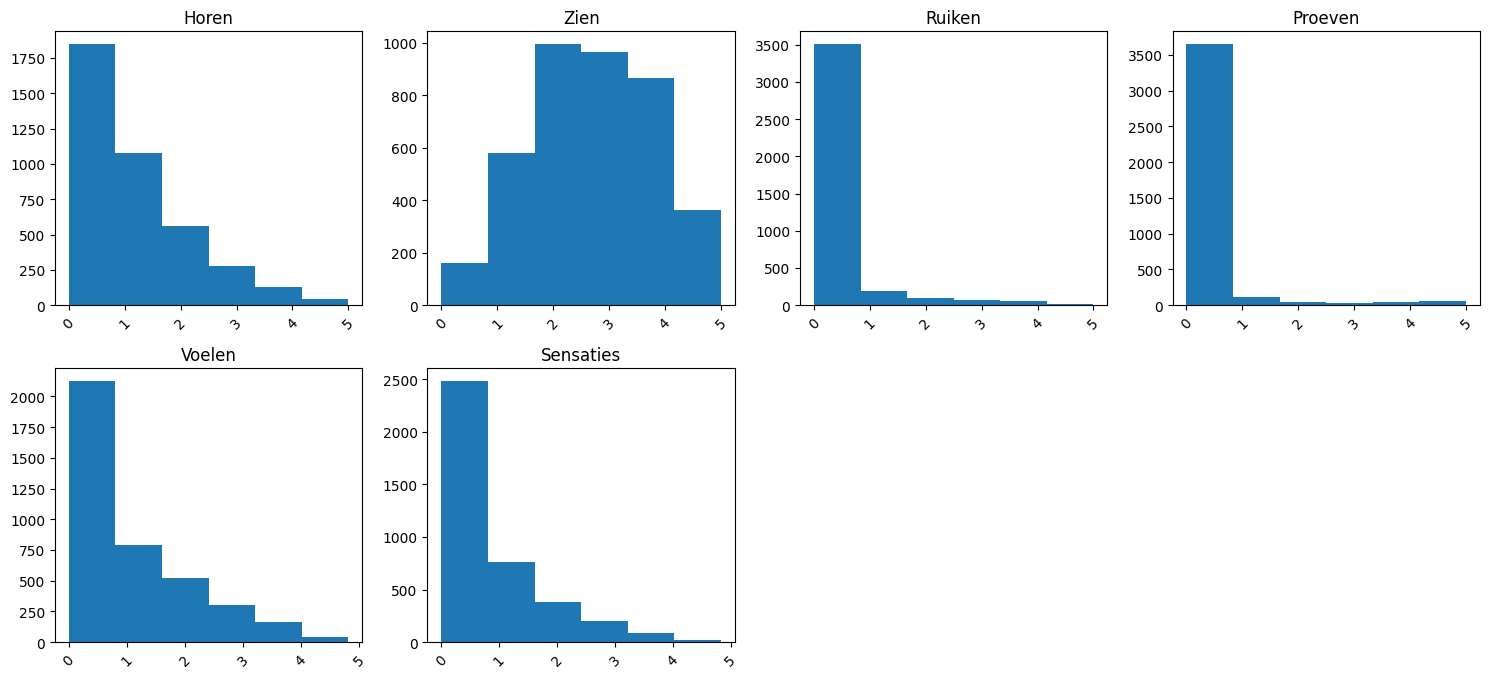

In [78]:

import matplotlib.pyplot as plt
cols = ['Horen', 'Zien', 'Ruiken', 'Proeven', 'Voelen', 'Sensaties']
fig, axes = plt.subplots(3, 4, figsize=(15, 10))  # 增大 figsize
axes = axes.flatten()
for ax, col in zip(axes, cols):
    df_common_train[col].dropna().hist(bins=6, ax=ax)
    ax.set_title(col)
    ax.tick_params(axis='x', rotation=45)
    ax.grid(False)
# 关闭多余子图（第 12 个）
if len(cols) < len(axes):
    for ax in axes[len(cols):]:
        ax.set_visible(False)
plt.tight_layout()
plt.show()

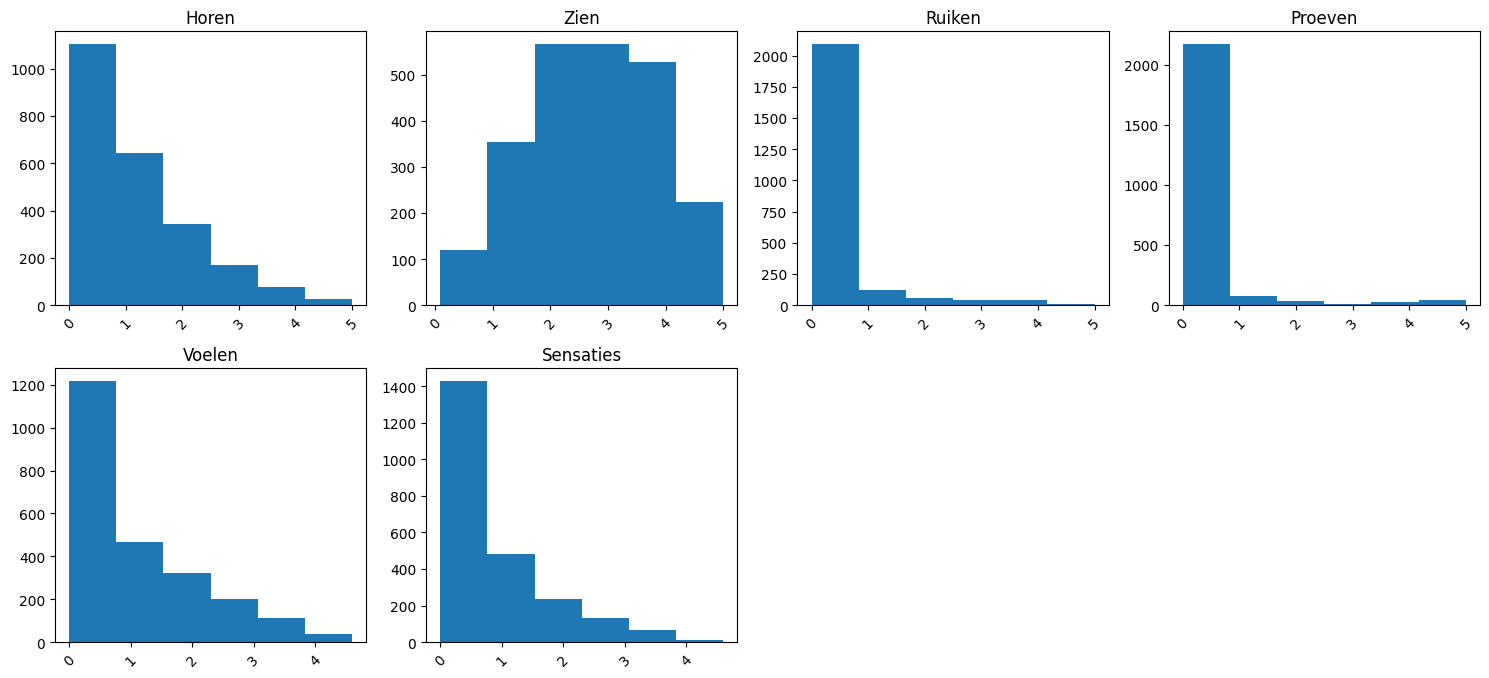

In [79]:
import matplotlib.pyplot as plt
cols = ['Horen', 'Zien', 'Ruiken', 'Proeven', 'Voelen', 'Sensaties']
fig, axes = plt.subplots(3, 4, figsize=(15, 10))  # 增大 figsize
axes = axes.flatten()
for ax, col in zip(axes, cols):
    df_2_train[col].dropna().hist(bins=6, ax=ax)
    ax.set_title(col)
    ax.tick_params(axis='x', rotation=45)
    ax.grid(False)
# 关闭多余子图（第 12 个）
if len(cols) < len(axes):
    for ax in axes[len(cols):]:
        ax.set_visible(False)
plt.tight_layout()
plt.show()

Auditory Gustatory Haptic Olfactory Visual Interoceptive
